# Orbits of Known Objects

galpy can look up the phase-space coordinates of known astronomical objects
by name, using SIMBAD or built-in catalogs. This makes it easy to compute
orbits for stars, clusters, galaxies, and solar system bodies.

In [1]:
%matplotlib inline
import numpy
from galpy.orbit import Orbit
from galpy.potential import MWPotential2014
import warnings

warnings.filterwarnings("ignore", category=RuntimeWarning)
warnings.filterwarnings("ignore", category=UserWarning)

## Looking up a single object

`Orbit.from_name` looks up built-in catalogs (or queries SIMBAD if
`astroquery` is installed) to get the phase-space coordinates of a named object.
`Orbit.from_name` supports **tab completion** in IPython/Jupyter for the list of
built-in objects (globular clusters, dwarf satellite galaxies, etc.).

<div class="alert alert-warning">

**Warning**

Orbits initialized using `Orbit.from_name` have physical output
*turned on by default*, so methods will return outputs in physical units unless
you call `o.turn_physical_off()`.

</div>

In [2]:
o = Orbit.from_name("NGC104")  # 47 Tucanae
print(o)
print("RA =", o.ra(), "deg")
print("Dec =", o.dec(), "deg")

RA = 6.024000000000262 deg
Dec = -72.08100000000005 deg


## Globular clusters

Many well-known globular clusters are in the built-in catalog.

In [3]:
o_oc = Orbit.from_name("NGC 5139")  # Omega Centauri
print("Omega Cen R =", o_oc.R(), "kpc")
print("Omega Cen z =", o_oc.z(), "kpc")

Omega Cen R = 6.20868822084256 kpc
Omega Cen z = 1.4146321192354743 kpc


## Satellite galaxies and multiple names

You can look up satellite galaxies and pass a list of names.

In [4]:
o_lmc = Orbit.from_name("LMC")
print("LMC distance =", o_lmc.dist(), "kpc")

# Multiple objects at once
os_mc = Orbit.from_name(["LMC", "SMC"])
print("Number of orbits:", os_mc.size)
print("Distances:", os_mc.dist())

LMC distance = 50.1 kpc
Number of orbits: 2
Distances: [50.1 62.8]


## Built-in collections

galpy has built-in collections for Milky Way globular clusters,
satellite galaxies, and the solar system.

In [5]:
# All MW globular clusters
gc = Orbit.from_name("MW globular clusters")
print("Number of globular clusters:", gc.size)

Number of globular clusters: 161


Similarly, all MW satellite galaxies:

In [6]:
# MW satellite galaxies
sat = Orbit.from_name("MW satellite galaxies")
print("Number of satellite galaxies:", sat.size)

Number of satellite galaxies: 50


And the solar system planets:

In [7]:
# Solar system
ss = Orbit.from_name("solar system")
print("Number of solar system bodies:", ss.size)

Number of solar system bodies: 8


## Integrating globular cluster orbits

Let's integrate the orbits of all MW globular clusters and plot them.

  0%|          | 0/161 [00:00<?, ?it/s]

 55%|█████▌    | 89/161 [00:00<00:00, 887.90it/s]

 64%|██████▍   | 103/161 [00:00<00:00, 968.45it/s]

 68%|██████▊   | 109/161 [00:00<00:00, 968.45it/s]

 71%|███████▏  | 115/161 [00:00<00:00, 968.45it/s]

...

 77%|███████▋  | 124/161 [00:00<00:00, 968.45it/s]

 77%|███████▋  | 124/161 [00:00<00:00, 968.45it/s]

 78%|███████▊  | 125/161 [00:00<00:00, 968.45it/s]

 78%|███████▊  | 126/161 [00:00<00:00, 968.45it/s]

 80%|████████  | 129/161 [00:00<00:00, 968.45it/s]

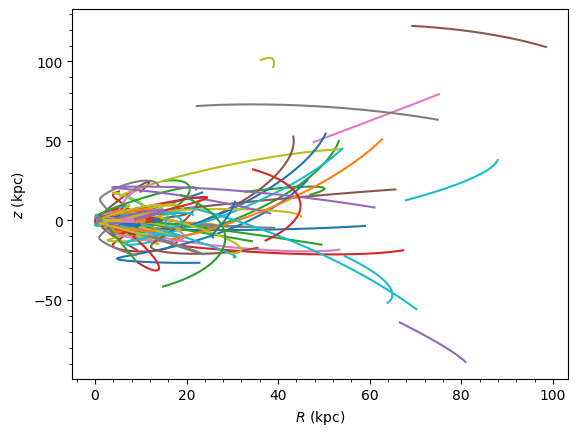

In [8]:
import numpy

ts = numpy.linspace(0.0, 10.0, 10000)
gc.integrate(ts, MWPotential2014)
gc.plot();

## Solar system example with KeplerPotential

Integrate the solar system planets in a Keplerian potential representing the Sun.

  0%|          | 0/8 [00:00<?, ?it/s]

 88%|████████▊ | 7/8 [00:00<00:00, 34.73it/s]

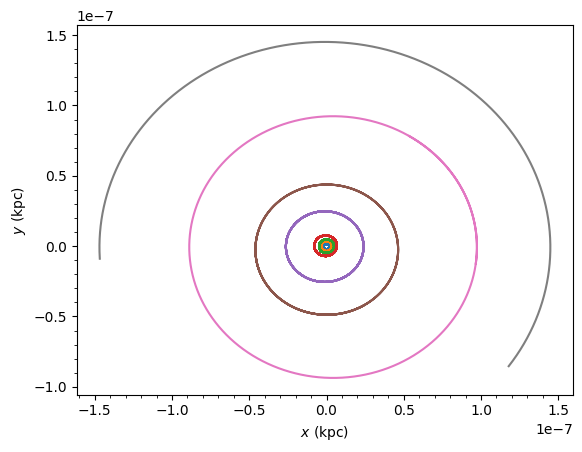

In [9]:
from galpy.potential import KeplerPotential
from galpy.util.conversion import get_physical
from astropy import units as u

ss = Orbit.from_name("solar system")
kp = KeplerPotential(amp=1.0 * u.Msun, **get_physical(ss))
ts = numpy.linspace(0.0, 100.0, 10001) * u.yr
ss.integrate(ts, kp)
ss.plot(d1="x", d2="y");